In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import re
import glob
import os 
from matplotlib.collections import LineCollection
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from scipy.stats import mannwhitneyu
from matplotlib.lines import Line2D

In [2]:
swarm1={"red":"in_silico_bots/bot_2022_10_07_09_19_50_PM.history",
"green":"in_silico_bots/bot_2022_10_07_08_18_13_PM.history",
"blue":"in_silico_bots/bot_2022_10_07_09_21_08_PM.history",
"purple":"in_silico_bots/bot_2022_10_07_09_16_39_PM.history"}

swarm2={"red":"in_silico_bots/bot_2022_10_07_08_18_13_PM.history",
"green":"in_silico_bots/bot_2022_10_07_09_21_08_PM.history",
"blue":"in_silico_bots/bot_2022_10_07_09_19_50_PM.history",
"purple":"in_silico_bots/bot_2022_10_07_09_16_39_PM.history"}

swarm3={"red":"in_silico_bots/bot_2022_10_07_09_16_53_PM.history",
"green":"in_silico_bots/bot_2022_10_07_09_16_57_PM.history",
"blue":"in_silico_bots/bot_2022_10_07_09_23_09_PM.history",
"purple":"in_silico_bots/bot_2022_10_07_09_18_59_PM.history"}

swarm4={"red":"in_silico_bots/bot_2022_10_07_09_22_26_PM.history",
"green":"in_silico_bots/bot_2022_10_07_09_22_01_PM.history",
"blue":"in_silico_bots/bot_2022_10_07_08_18_26_PM.history",
"purple":"in_silico_bots/bot_2022_10_07_09_22_39_PM.history"}

swarm5={"red":"in_silico_bots/bot_2022_10_07_09_18_55_PM.history",
"green":"in_silico_bots/bot_2022_10_07_08_19_24_PM.history",
"blue":"in_silico_bots/bot_2022_10_07_09_22_34_PM.history",
"purple":"in_silico_bots/bot_2022_10_07_09_22_59_PM.history"}

swarm6={"red":"in_silico_bots/bot_2022_10_07_09_21_08_PM.history",
"green":"in_silico_bots/bot_2022_10_07_09_19_50_PM.history",
"blue":"in_silico_bots/bot_2022_10_07_08_18_13_PM.history",
"purple":"in_silico_bots/bot_2022_10_07_09_16_39_PM.history"}

swarm7 = {"red":'in_silico_bots/bot_2022_10_07_09_18_05_PM.history',
            "green":'in_silico_bots/bot_2022_10_07_09_20_52_PM.history',
            "blue":'in_silico_bots/bot_2022_10_07_08_18_20_PM.history',
            "purple":'in_silico_bots/bot_2022_10_07_09_19_30_PM.history'}

swarm8 = {"red":'in_silico_bots/bot_2022_10_07_08_18_13_PM.history',
            "green":'in_silico_bots/bot_2022_10_07_09_19_50_PM.history',
            "blue":'in_silico_bots/bot_2022_10_07_09_21_08_PM.history',
            "purple":'in_silico_bots/bot_2022_10_07_09_16_39_PM.history'}



swarm_dict = {"1":swarm1, "2":swarm2, "3":swarm3, "4":swarm4, "5":swarm5, "6":swarm6, "7":swarm7, "8":swarm8}

In [3]:
def parse_history_single_bot(file_name):

    os.system(f"cp {file_name} .")
    f  = open(file_name, "r")
    str_file = f.read()
    f.close()

    lst_file = str_file.split(">>>")
    lst_file = lst_file[1:]
    
    parsed_all_data = []
    for line in lst_file:
        p_line = line.split(";")
        if len(p_line) <= 2:
            continue
        parsed_all_data.append(line.split(";"))

    x_list, y_list = [], []

    for list in parsed_all_data: 
        x_sum = 0
        y_sum = 0
        count = 0
        for data_points in list:
            points = data_points.split(",")
            points = points[:len(points) -1]

            if len(points) > 5: #get xy coords
                x_sum+=float(points[0])
                y_sum+=float(points[1])
                count+=1
        if count != 0:
            x_list.append(x_sum/count)
            y_list.append(y_sum/count)
 
    return x_list, y_list



def normalize(pts):
    """Center and scale to unit RMS — order-independent."""
    pts = pts - pts.mean(axis=0)
    pts = pts / np.sqrt((pts ** 2).sum(axis=1).mean())
    return pts



def compare_trajectories(xy1, xy2):
    mat1 = normalize(xy1)
    mat2 = normalize(xy2)
    n = min(len(mat1), len(mat2))
    mat1 = mat1[np.round(np.linspace(0, len(mat1) - 1, n)).astype(int)]
    mat2 = mat2[np.round(np.linspace(0, len(mat2) - 1, n)).astype(int)]
    cost_matrix = cdist(mat1, mat2)
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    return cost_matrix[row_ind, col_ind].mean()



def load_silico_vitro_scores(swarm_list, max_per_swarm=4):
    """Return list of Δ scores (in silico vs in vitro) for given swarms."""
    scores = []
    for swarm in swarm_list:
        file_path = glob.glob(f'swarm_data\Swarm_{swarm}\*\*.csv')
        count = 0
        for file in file_path:
            if 'Trial' in file: continue
            if (swarm == 1 or swarm == 3) and 'fixed.csv' not in file: continue
            df = pd.read_csv(file)
            try:
                color_match = re.search(r'Swarm\w_Bot\d_(\w+)_*', file)
                color = color_match.group(1).lower().split('bot')[0].split('_fixed')[0]
            except:
                color_match = re.search(r'Swarm\d_(\w+)Bot*', file)
                color = color_match.group(1).lower().split('bot')[0].split('_fixed')[0]

            x, y = parse_history_single_bot(swarm_dict[str(swarm)][color])
            silico_pts = np.column_stack([np.array(x) - np.mean(x),
                                          np.array(y) - np.mean(y)])
            vitro_pts  = np.column_stack([df['x'].values - np.mean(df['x'].values),
                                          df['y'].values - np.mean(df['y'].values)])
            scores.append(compare_trajectories(silico_pts, vitro_pts))
            count += 1
            if count >= max_per_swarm: break
    return scores


  Mann-Whitney U statistic : 165.0
  p-value (two-sided)      : 0.1689  (not significant)


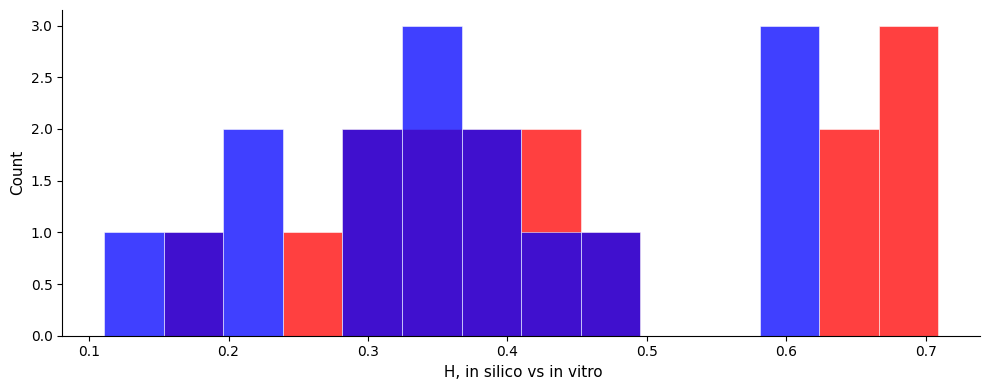

In [4]:
swarms  = [1, 2, 3, 4, 5, 6, 7, 8]
evolved = [1, 2, 6, 8]
random  = [s for s in swarms if s not in evolved]

evolved_scores = load_silico_vitro_scores(evolved)
random_scores  = load_silico_vitro_scores(random)

all_scores = evolved_scores + random_scores
bins = np.linspace(min(all_scores), max(all_scores), 15)

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(evolved_scores, bins=bins, color='red', alpha=0.75,
        label=f'Evolved  (mean={np.mean(evolved_scores):.3f})', edgecolor='white', lw=0.5)
ax.hist(random_scores,  bins=bins, color='blue', alpha=0.75,
        label=f'Random   (mean={np.mean(random_scores):.3f})',  edgecolor='white', lw=0.5)


ax.set_xlabel(' H, in silico vs in vitro', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("traj_comp.png", dpi=400)


n_ev  = len(evolved_scores)
n_rnd = len(random_scores)

# Mann-Whitney U — non-parametric, does not assume normality
stat, p_value = mannwhitneyu(evolved_scores, random_scores, alternative='two-sided')

print(f"\n  Mann-Whitney U statistic : {stat:.1f}")
print(f"  p-value (two-sided)      : {p_value:.4f}  {'*** significant (p<0.05)' if p_value < 0.05 else '(not significant)'}")

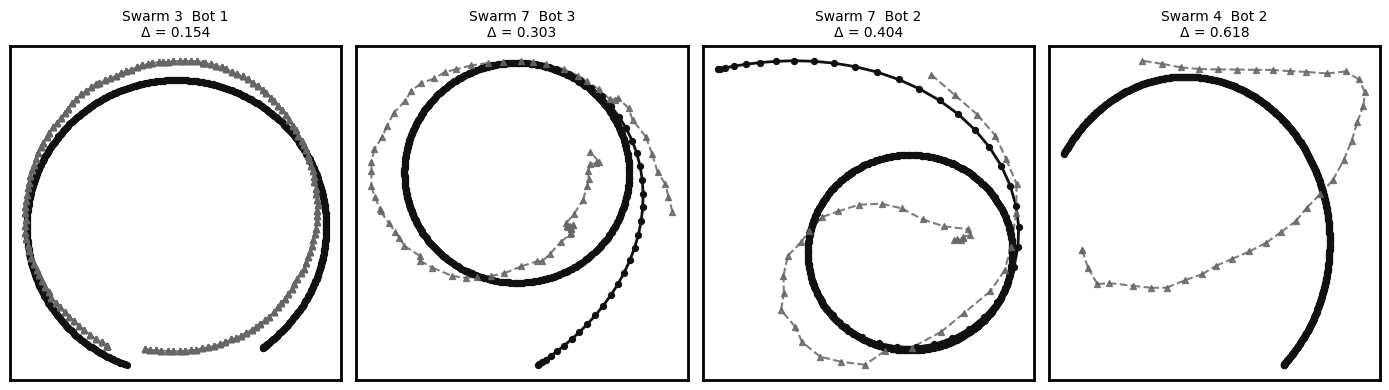

In [5]:

def plot_styled_trajectory(ax, x, y, color, marker, alpha=1.0, linestyle='-', linewidth=1.5):
    """Plot trajectory with a single solid color and distinct marker shape."""
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, colors=[color] * len(segments),
                        linewidth=linewidth, linestyle=linestyle, alpha=alpha)
    ax.add_collection(lc)
    ax.scatter(x, y, color=color, marker=marker, s=18, zorder=3, alpha=alpha)
    ax.autoscale()

SILICO_COLOR  = '#111111'   # near-black
VITRO_COLOR   = '#666666'   # dark grey
SILICO_MARKER = 'o'         # circle
VITRO_MARKER  = '^'         # triangle

SELECTED = [ #plot these bots 
    (3, 1),
    (7, 3),
    (7, 2),
    (4, 2),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, (swarm, bot_idx) in zip(axes, SELECTED):

    file_path = sorted(glob.glob(f'swarm_data\Swarm_{swarm}\*\*.csv'))

    filtered = []
    for f in file_path:
        if 'Trial' in f: continue
        if (swarm == 1 or swarm == 3) and 'fixed.csv' not in f: continue
        filtered.append(f)

    file = filtered[bot_idx - 1]
    df   = pd.read_csv(file)

    try:
        color_match = re.search(r'Swarm\w_Bot\d_(\w+)_*', file)
        color = color_match.group(1).lower().split('bot')[0].split('_fixed')[0]
    except:
        color_match = re.search(r'Swarm\d_(\w+)Bot*', file)
        color = color_match.group(1).lower().split('bot')[0].split('_fixed')[0]

    x, y = parse_history_single_bot(swarm_dict[str(swarm)][color])
    x, y = np.array(x), np.array(y)

    silico_pts = np.column_stack([x - np.mean(x), y - np.mean(y)])
    vitro_pts  = np.column_stack([df['x'].values - np.mean(df['x'].values),
                                  df['y'].values - np.mean(df['y'].values)])

    norm_silico = normalize(silico_pts)
    norm_vitro  = normalize(vitro_pts)

    score       = compare_trajectories(silico_pts, vitro_pts)
    title_color = plt.cm.RdYlGn(1 - min(score / 0.5, 1.0))

    plot_styled_trajectory(ax, norm_silico[:, 0], norm_silico[:, 1],
                           color=SILICO_COLOR, marker=SILICO_MARKER,
                           alpha=1.0, linestyle='-', linewidth=2.0)

    plot_styled_trajectory(ax, norm_vitro[:, 0], norm_vitro[:, 1],
                           color=VITRO_COLOR, marker=VITRO_MARKER,
                           alpha=0.85, linestyle='--', linewidth=1.5)

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

    ax.set_title(f'Swarm {swarm}  Bot {bot_idx}\nΔ = {score:.3f}',
                 fontsize=10, color='black')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig("traj_comp.png", dpi=300)